# Objectif 

Date : 09/10/2025

L'objectif du notebook est de localiser la source en mouvement par une méthode TOA. 
Les positions des hydrophones dans le bassin sont supposées connues et ont été préalablement estimée par TOA à l'aide des enregistrements en statique aux positions P1 à P6. 

In [1]:
import sys
sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

import os
import numpy as np
import xarray as xr
from utils import load_fiberscope_data, all_arrivals_dynamic
from real_data_analysis.fiberscope_20.src.fiberscope_recording import (
    FiberscopeDynamicRecording,
)
from publication.publication_figure import PubFigure

import matplotlib.pyplot as plt

PubFigure()

In [2]:
# Define usefull paths

# Raw data 
tdms_data_root = (
    r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\data\Fiberscope_campagne_oct_2024"
)

# Folder to save results
img_root = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\img\dynamic_src_localization_toa"
root_data_dyn = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\data\dynamic"

if not os.path.exists(img_root):
    os.makedirs(img_root)
if not os.path.exists(root_data_dyn):
    os.makedirs(root_data_dyn)

In [3]:
fs_dynamic = FiberscopeDynamicRecording()

# Analyse des signaux reçus 

## Chargement des signaux 

In [4]:
load_tdms_data = False

if load_tdms_data:

    date = fs_dynamic.recording_name.split("T")[0]
    data_path = os.path.join(tdms_data_root, f"Campagne_{date}")
    file_name = f"{fs_dynamic.recording_name}.tdms"
    file_path = os.path.join(data_path, file_name)

    data = load_fiberscope_data(file_path, subsampling_factor=5)

    # Save data as netcdf
    data.to_netcdf(os.path.join(root_data_dyn, f"{fs_dynamic.recording_name}.nc"))

else: 
    # Load pre-saved data
    data = xr.load_dataset(
        os.path.join(root_data_dyn, f"{fs_dynamic.recording_name}.nc")
    )

## Visualisation de quelques signaux 

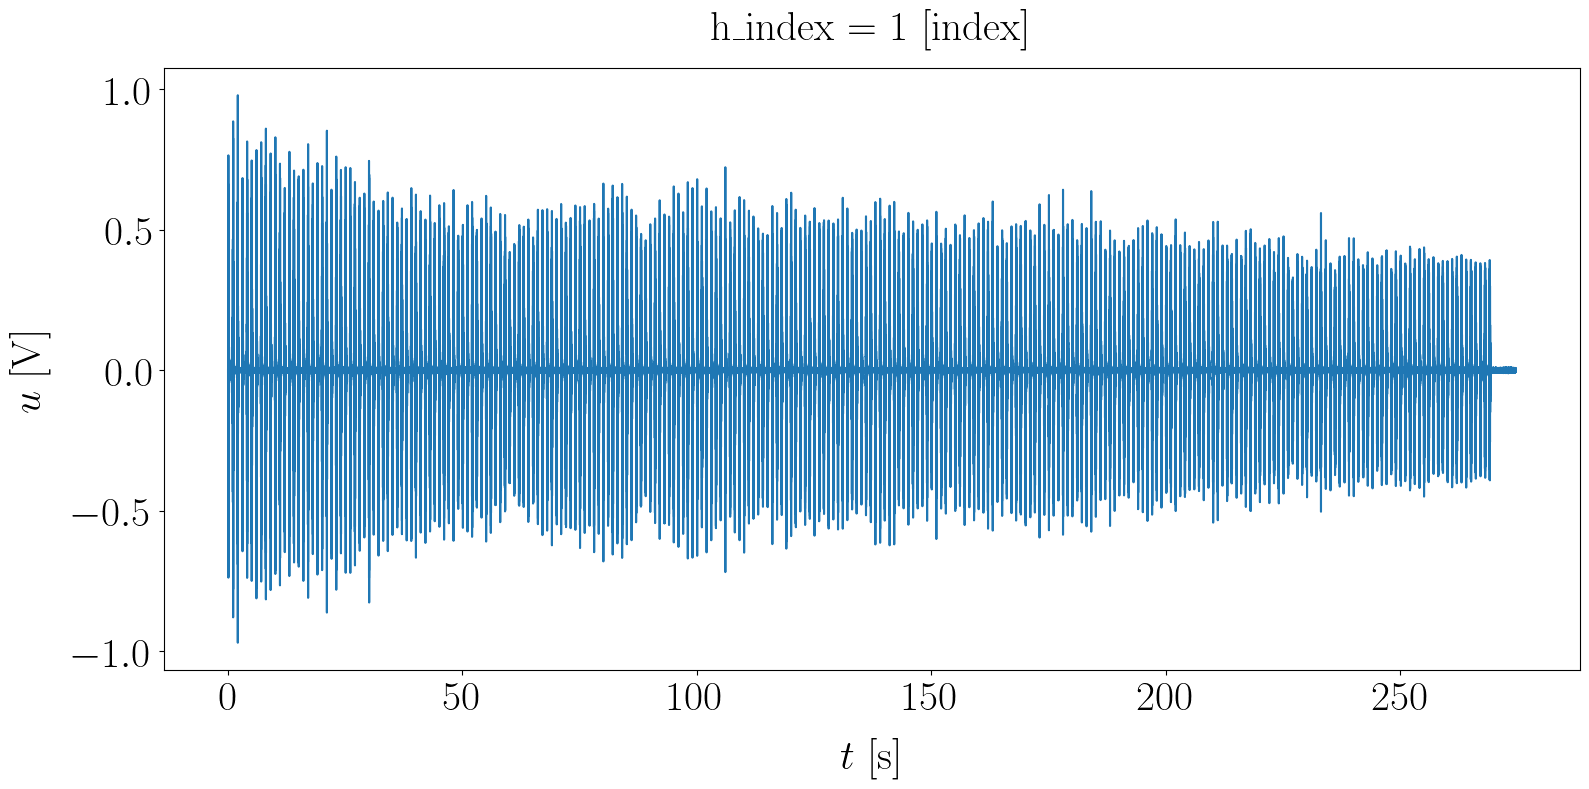

In [5]:
# Visualize single channel data
sig = data.signal.sel(h_index=1).plot()

Text(0.5, 0, 'Time [s]')

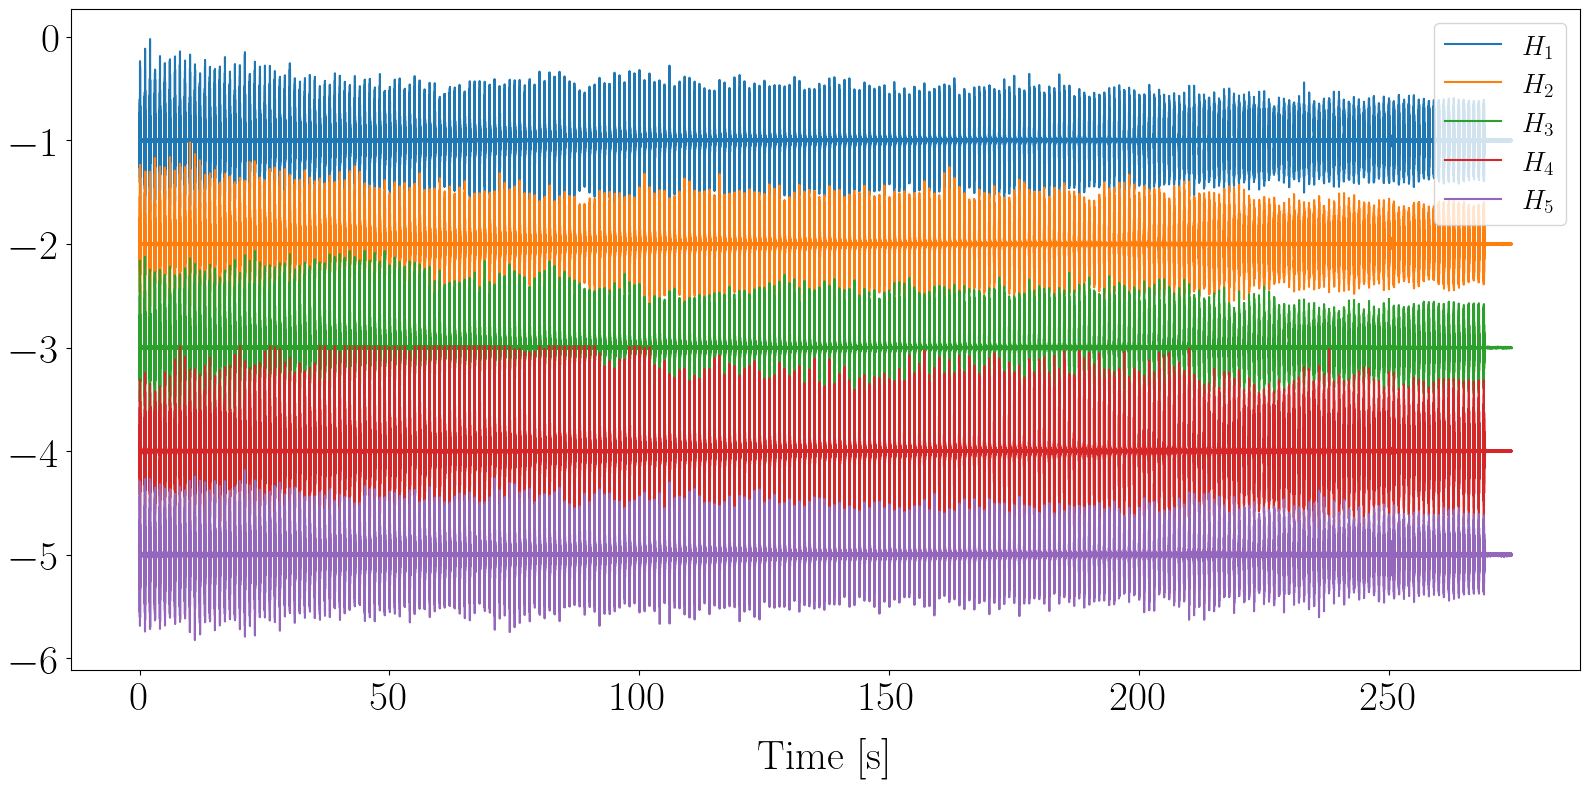

In [6]:
# Plot raw data stack plot 
delta_y = 1
plt.figure()
for i_h in data.h_index.values:
    sig = data.signal.sel(h_index=i_h).values
    plt.plot(data.time, sig - i_h * delta_y, label=rf"$H_{i_h}$")
plt.legend(loc="upper right")
plt.xlabel("Time [s]")

Text(0.5, 0, 'Time [s]')

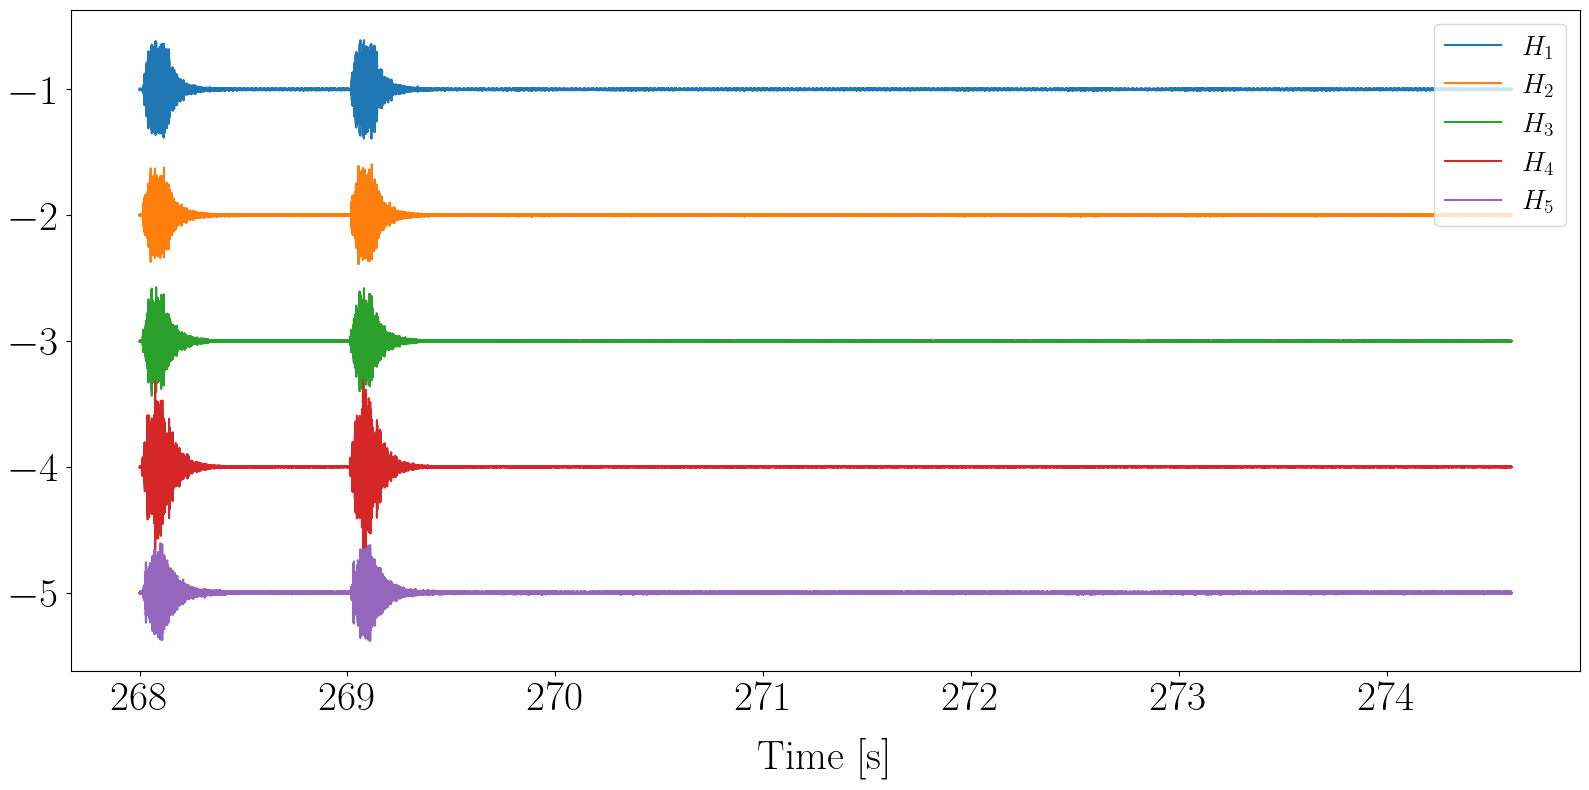

In [7]:
# ZOOM on raw data stack plot
delta_y = 1
t_min = 268
t_max = 278
plt.figure()
for i_h in data.h_index.values:
    sig = data.signal.sel(h_index=i_h).sel(time=slice(t_min, t_max))
    plt.plot(sig.time, sig - i_h * delta_y, label=rf"$H_{i_h}$")
plt.legend(loc="upper right")
plt.xlabel("Time [s]")

## Définition de la stratégie de localisation 

La localisation est effectuée pour chacune des émissions. La trajectoire de la source est obtenue en itérant les étapes suivantes :

* 1) Détection des temps d'arrivées sur les 5 hydrophones
* 2) Calcul de la position estimée de la source par LMS 


In [8]:
def dynamic_localization_toa(xr_data, fs_dyn):
    print("Dynamic source localization using TOA")
    print(f"Source is mooving from {fs_dyn.src_start_pos} to {fs_dyn.src_end_pos} at a speed of {fs_dyn.src_speed} m/s")

    # Add fs info to fs_dyn
    fs_sweep_info = fs_dyn.signal
    fs_sweep_info.fs = xr_data.fs
    t_obs, d2_obs = all_arrivals_dynamic(
        xr_data=xr_data,
        fs_sweep_info=fs_sweep_info,
        c=1500,
    )

    print(t_obs, d2_obs)

In [9]:
dynamic_localization_toa(xr_data=data, fs_dyn=fs_dynamic)

Dynamic source localization using TOA
Source is mooving from P1 to P4 at a speed of 0.1 m/s
{'H1': array([0.0036  , 0.0036  , 0.00365 , 0.003725, 0.003775, 0.003825,
       0.003875, 0.0039  , 0.00395 , 0.004   , 0.00405 , 0.004125,
       0.00415 , 0.0042  , 0.004275, 0.0043  , 0.004375, 0.004425,
       0.00445 , 0.004525, 0.004575, 0.004625, 0.004675, 0.004725,
       0.0048  , 0.00485 , 0.0049  , 0.00495 , 0.005025, 0.005075,
       0.005125, 0.0052  , 0.00525 , 0.0053  , 0.005375, 0.005425,
       0.005475, 0.005525, 0.005575, 0.00565 , 0.0057  , 0.005775,
       0.005825, 0.0059  , 0.005975, 0.006   , 0.00605 , 0.006125,
       0.006175, 0.00625 , 0.0063  , 0.006375, 0.00645 , 0.0065  ,
       0.006525, 0.0066  , 0.006675, 0.00675 , 0.0068  , 0.006875,
       0.0069  , 0.006975, 0.00705 , 0.007275, 0.007175, 0.007225,
       0.0073  , 0.00735 , 0.007425, 0.007475, 0.007525, 0.0076  ,
       0.007675, 0.007725, 0.0078  , 0.00785 , 0.0079  , 0.007975,
       0.00805 , 0.0081  , 0.0